# Branch libraries, feedback and the critical boron search

A real core does not sit at one state. Fuel temperature, moderator density and
boron concentration all move, and the group constants move with them. OpenNDM
stores that as a **branch-parameterised library**: one set of cross sections
per point on a grid of state variables, interpolated multilinearly at solve
time.

This notebook builds a small branch table by hand, interpolates it, and uses
it to search for the critical boron concentration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import openndm

print("openndm", openndm.__version__)

openndm 0.1.0


## 1. Declaring the axes

Axes are named, and any names will do — the library does not care what they
mean. Declare them *before* filling compositions, because declaring them
resizes the storage to one composition set per grid point.

In [2]:
FUEL_TEMPERATURES = [560.0, 900.0, 1200.0]      # K
BORON = [0.0, 800.0, 1600.0]                    # ppm

lib = openndm.XSLibrary(n_groups=2, n_compositions=2)
lib.set_axes([
    ("fuel_temperature", FUEL_TEMPERATURES),
    ("boron", BORON),
])
print(f"{lib.n_states} branch states over {[a.name for a in lib.axes]}")

9 branch states over ['fuel_temperature', 'boron']


## 2. Filling the table

A real table comes from `openndm.gc.BranchDriver`, which runs one OpenMC case
per grid point. Here we fabricate a plausible dependence instead, so the
notebook runs anywhere: a square-root Doppler effect on the fast absorption
and a linear boron effect on the thermal.

The state index is row-major over the axes in declaration order, which is
exactly what `BranchGrid` produces, so the two line up without any bookkeeping.

In [3]:
import itertools

def fuel_cross_sections(temperature, boron):
    doppler = 4.0e-4 * (np.sqrt(temperature) - np.sqrt(560.0))
    return {
        "D": [1.5, 0.4],
        "absorption": [0.0100 + doppler, 0.0850 + 1.0e-5 * boron],
        "nu_fission": [0.0, 0.155],
        "kappa_fission": [0.0, 0.155],
        "chi": [1.0, 0.0],
        "scatter": [[0.0, 0.020], [0.0, 0.0]],
    }

for state, (temperature, boron) in enumerate(
        itertools.product(FUEL_TEMPERATURES, BORON)):
    lib.set_composition(0, state=state, **fuel_cross_sections(temperature, boron))
    lib.set_composition(
        1, state=state, D=[2.0, 0.3],
        absorption=[0.0, 0.010 + 3.0e-6 * boron],
        scatter=[[0.0, 0.040], [0.0, 0.0]])

lib.finalize()
print(lib)

<XSLibrary 2 groups, 2 compositions, 9 branch states over ['fuel_temperature', 'boron']>


## 3. Interpolating

`interpolate` collapses the table to a single state. Interpolation is
multilinear and therefore *exact* on data that is linear in the axes, which is
worth checking when you build a table.

In [4]:
hot = lib.interpolate(fuel_temperature=900.0, boron=800.0)
print("at 900 K and 800 ppm:")
print("  fast absorption   ", hot.composition(0).absorption[0])
print("  thermal absorption", hot.composition(0).absorption[1])

# Halfway between two grid points on the boron axis, where the dependence is
# linear, interpolation reproduces the underlying model exactly.
mid = lib.interpolate(fuel_temperature=560.0, boron=400.0)
expected = 0.0850 + 1.0e-5 * 400.0
print(f"\nlinear axis check: {mid.composition(0).absorption[1]:.8f} "
      f"vs {expected:.8f}")

at 900 K and 800 ppm:
  fast absorption    0.012534272347040614
  thermal absorption 0.093

linear axis check: 0.08900000 vs 0.08900000


Outside the grid the behaviour is configurable: `clamp` (the default),
`linear` extrapolation, or `error`.

In [5]:
for policy in ("clamp", "linear", "error"):
    lib.extrapolation = policy
    try:
        value = lib.interpolate(fuel_temperature=2000.0,
                                boron=800.0).composition(0).absorption[0]
        print(f"{policy:7s} -> fast absorption {value:.6f}")
    except openndm.InputError as exc:
        print(f"{policy:7s} -> raises: {exc}")
lib.extrapolation = "clamp"

clamp   -> fast absorption 0.014391
linear  -> fast absorption 0.019341
error   -> raises: branch coordinate 2000.000000 is outside axis 'fuel_temperature'


## 4. A core, at two states

A branch library cannot be solved directly; collapse it first. That is
enforced rather than implicit, because silently solving at some default state
would be a very easy way to get a plausible wrong answer.

In [6]:
core = np.zeros((10, 9, 9), dtype=int)
core[:, 8, :] = 1
core[:, :, 8] = 1
core[0] = core[-1] = 1

geom = openndm.Geometry.from_lattice(
    core, pitch=(20.0, 20.0, 20.0),
    boundaries={"x_min": "reflective", "y_min": "reflective",
                "x_max": "zero_flux", "y_max": "zero_flux",
                "z_min": "vacuum", "z_max": "vacuum"})
settings = openndm.Settings(kernel="sanm", verbosity=0)

try:
    openndm.Model(geom, lib, settings)
except openndm.InputError as exc:
    print("as expected:", exc)

for temperature in (560.0, 900.0, 1200.0):
    state = lib.interpolate(fuel_temperature=temperature, boron=800.0)
    k = openndm.Model(geom, state, settings).solve().k_eff
    print(f"  {temperature:6.0f} K  k_eff = {k:.6f}")

as expected: a branch-parameterised library must be collapsed first; call library.interpolate(**state)


     560 K  k_eff = 1.084024


     900 K  k_eff = 1.001697


    1200 K  k_eff = 0.948921


The eigenvalue falls as the fuel heats. That is the Doppler effect, and its
sign is the single most important thing to get right in a feedback model.

## 5. Boron worth

worth of 1600 ppm: 17208 pcm (10.75 pcm/ppm)


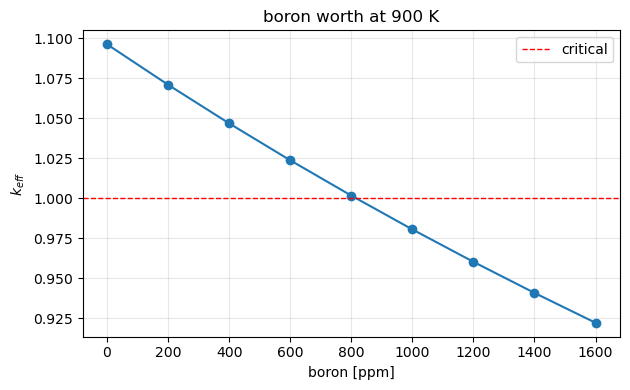

In [7]:
concentrations = np.linspace(0.0, 1600.0, 9)
eigenvalues = []
for ppm in concentrations:
    state = lib.interpolate(fuel_temperature=900.0, boron=float(ppm))
    eigenvalues.append(openndm.Model(geom, state, settings).solve().k_eff)
eigenvalues = np.array(eigenvalues)

worth = 1e5 * (1.0 / eigenvalues[-1] - 1.0 / eigenvalues[0])
print(f"worth of {concentrations[-1]:.0f} ppm: {worth:.0f} pcm "
      f"({worth / concentrations[-1]:.2f} pcm/ppm)")

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(concentrations, eigenvalues, "o-")
ax.axhline(1.0, color="r", ls="--", lw=1, label="critical")
ax.set_xlabel("boron [ppm]"); ax.set_ylabel(r"$k_{eff}$")
ax.set_title("boron worth at 900 K")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

The core is supercritical unborated and subcritical at 1600 ppm, so a
critical concentration exists inside the range. That is worth checking before
running a search: if the target lies outside the reachable range the search
cannot converge, and OpenNDM says so explicitly rather than reporting a
generic failure.

## 6. The critical boron search

`Model.search_boron` iterates to a target eigenvalue with a secant method and
a bisection fallback. You supply the callback that applies a concentration,
which keeps the boron model in your hands rather than hard-coded in the
solver — here it is the branch table.

In [8]:
base = lib.interpolate(fuel_temperature=900.0, boron=0.0)
model = openndm.Model(geom, base, settings)

def apply_boron(library, ppm):
    """Re-interpolate the branch table and copy it into the live library."""
    state = lib.interpolate(fuel_temperature=900.0, boron=float(ppm))
    for c in range(library.n_compositions):
        source = state.composition(c)
        library.set_composition(
            c,
            D=source.D, absorption=source.absorption,
            nu_fission=source.nu_fission, kappa_fission=source.kappa_fission,
            chi=source.chi,
            scatter=np.asarray(source.scatter).reshape(2, 2),
        )
    library.finalize(warn=False)

search = model.search_boron(apply_boron, target_k=1.0, guess=400.0,
                            bracket=(0.0, 1600.0))
print(search)
print(f"\nconverged to {search.boron:.1f} ppm in {search.iterations} solves")
print("\nsearch history:")
for ppm, k in search.history:
    print(f"  {ppm:8.1f} ppm  ->  k_eff {k:.6f}")

<BoronSearchResult boron=815.7 ppm k_eff=1.000000 iterations=5>

converged to 815.7 ppm in 5 solves

search history:
     400.0 ppm  ->  k_eff 1.046813
     500.0 ppm  ->  k_eff 1.035157
     801.6 ppm  ->  k_eff 1.001524
     815.3 ppm  ->  k_eff 1.000050
     815.7 ppm  ->  k_eff 1.000000


## 7. Loading pattern studies

Shuffling only means something when the assemblies differ, so this section
uses a three-zone core: fresh fuel on the inside, twice-burnt on the outside.
`sweep` mutates the model and re-solves in memory, warm starting each case
from the last.

In [9]:
zoned = openndm.XSLibrary(n_groups=2, n_compositions=4)
# Three fuel zones of decreasing reactivity, plus the reflector.
for index, nu_fission in enumerate((0.170, 0.155, 0.140)):
    zoned.set_composition(
        index, D=[1.5, 0.4], absorption=[0.0100, 0.0850 + 1.0e-5 * 800.0],
        nu_fission=[0.0, nu_fission], kappa_fission=[0.0, nu_fission],
        chi=[1.0, 0.0], scatter=[[0.0, 0.020], [0.0, 0.0]])
zoned.set_composition(
    3, D=[2.0, 0.3], absorption=[0.0, 0.010 + 3.0e-6 * 800.0],
    scatter=[[0.0, 0.040], [0.0, 0.0]])
zoned.finalize()

# A checkerboard of the three zones, reflector on the outside.
pattern = np.array([
    [0, 1, 0, 1, 0, 1, 2, 3],
    [1, 0, 1, 0, 1, 0, 2, 3],
    [0, 1, 0, 1, 0, 2, 2, 3],
    [1, 0, 1, 0, 1, 2, 3, 3],
    [0, 1, 0, 1, 2, 2, 3, 3],
    [1, 0, 2, 2, 2, 3, 3, 3],
    [2, 2, 2, 3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3, 3, 3, 3],
])
zoned_core = np.repeat(pattern[np.newaxis, :, :], 8, axis=0)
zoned_core[0] = zoned_core[-1] = 3        # axial reflector

zoned_geom = openndm.Geometry.from_lattice(
    zoned_core, pitch=(20.0, 20.0, 20.0),
    boundaries={"x_min": "reflective", "y_min": "reflective",
                "x_max": "zero_flux", "y_max": "zero_flux",
                "z_min": "vacuum", "z_max": "vacuum"})

lp_model = openndm.Model(zoned_geom, zoned, settings)
reference = lp_model.solve()
print(f"reference   k_eff {reference.k_eff:.6f}   F_dH {reference.f_dh:.4f}")

reference   k_eff 1.119842   F_dH 2.9619


In [10]:
nx = zoned_geom.shape[2]

def position(index):
    return index % nx, index // nx

# An out-in shuffle: fresh fuel from the centre exchanged with twice-burnt
# fuel from the periphery. Pick pairs whose compositions actually differ --
# on a checkerboard it is easy to choose two positions of the same zone and
# wonder why nothing happens.
swaps = [(0, 6), (2, 6 * nx + 2), (2 * nx, 5 * nx + 2), (2 * nx + 2, 5 * nx + 4)]
for a, b in swaps:
    ca = pattern[a // nx, a % nx]
    cb = pattern[b // nx, b % nx]
    assert ca != cb, f"swap {position(a)}<->{position(b)} is a no-op"
    print(f"  {position(a)} zone {ca}  <->  {position(b)} zone {cb}")
print()

def mutate(model, case):
    a, b = case
    model.swap_assemblies(a, b)

results = lp_model.sweep(mutate, swaps)
print(f"{'swap':>22} {'k_eff':>10} {'vs ref':>10} {'F_dH':>8} {'outers':>7}")
for (a, b), r in zip(swaps, results):
    label = f"{position(a)} <-> {position(b)}"
    print(f"{label:>22} {r.k_eff:10.6f} {1e5 * (r.k_eff - reference.k_eff):+10.1f} "
          f"{r.f_dh:8.4f} {r.outer_iterations:7d}")

  (0, 0) zone 0  <->  (6, 0) zone 2
  (2, 0) zone 0  <->  (2, 6) zone 2
  (0, 2) zone 0  <->  (2, 5) zone 2
  (2, 2) zone 0  <->  (4, 5) zone 2



                  swap      k_eff     vs ref     F_dH  outers
     (0, 0) <-> (6, 0)   1.108629    -1121.3   2.0239      13
     (2, 0) <-> (2, 6)   1.100889    -1895.3   2.2003      14
     (0, 2) <-> (2, 5)   1.093956    -2588.5   1.7890      13
     (2, 2) <-> (4, 5)   1.085795    -3404.7   1.8560      15


Each swap is cumulative, since `sweep` mutates the model in place, so the
rows compound rather than each being measured against the reference alone.
Nothing here touches the filesystem, and the solve releases the GIL, so a
search over loading patterns can be driven from Python threads.

## Next

- `openndm.gc.BranchGrid` and `BranchDriver` build a real table from OpenMC,
  with checkpointing, resume, and HPC job-array emission for the thousands of
  cases a five-axis table needs.
- `XSLibrary.to_hdf5` and `from_hdf5` round-trip a branch table, axes and all.
- `docs/user-guide.md` documents the full API.